# Quantify Risk: Generate Risk metrics
How does increasing renewable penetration affect grid variability?

In power systems, risk occurs when demand changes too fast and generators cannot ramp fast enough. 

So the core risk driver = extreme ramps, not average variability.
Therefore, metrics should measure:
1.	Extreme ramps 
2.	Frequency of extreme ramps 
3.	Sustained ramps 
4.	Forecast difficulty 

RISK metrics included in this anlysis: 
1. Maximum Hourly Ramp: directly measures worst stress event 
2. Tail Probability (95%): measures how often extreme ramps occur based on today’s extreme grid stress level. Will apply different renewable senarios to quantify how often future system conditions exceed baseline extreme ramp levels.
3. Conditional Tail Expectation (CVaR-like): measures severity after extreme event happens 
4. 3-hour Ramp Magnitude: grid operators worry about sustained ramps 

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("C:/Renewable-PowerGrid-Risk")
PROCESSED_DIR = ROOT / 'data' / 'processed'

df=pd.read_csv(PROCESSED_DIR / 'hourly_load_renewable_merged.csv', parse_dates=['datetime'])
print(df.shape)

(26310, 23)


## Calculate RISK metrics
In this analysis, I choose these 4 to measure RISK: Maximum Ramp, Tail Probability (95%), Conditional Tail Expectation (CVaR-like), 3-hour Ramp Magnitude

In [2]:
from pathlib import Path
import sys

# Try likely working directories and pick the one that contains src/metrics.py
candidate_roots = [Path.cwd().resolve(), Path.cwd().resolve().parent]
project_root = next(
    (p for p in candidate_roots if (p / "src" / "metrics.py").exists()),
    None,
 )

# Adds src to sys.path
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
print(sys.path)

print(f"Project root directory: {project_root}")
print(f"Source directory: {src_path}")

from metrics import compute_risk_metrics

print(compute_risk_metrics(df))

['C:\\Renewable-PowerGrid-Risk\\src', 'c:\\Renewable-PowerGrid-Risk\\notebooks', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env\\python39.zip', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env\\DLLs', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env\\lib', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env', '', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env\\lib\\site-packages', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env\\lib\\site-packages\\win32', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env\\lib\\site-packages\\win32\\lib', 'c:\\Users\\xplv\\AppData\\Local\\anaconda3\\envs\\mlrun_env\\lib\\site-packages\\Pythonwin']
Project root directory: C:\Renewable-PowerGrid-Risk
Source directory: C:\Renewable-PowerGrid-Risk\src
{'max_ramp_up': 15862.660755310055, 'max_ramp_down': -14803.3171525065, 'threshold_P95': 5372.963952272039, 'tail_probability': 0.050019004180919806, 'conditional_tail': 7133

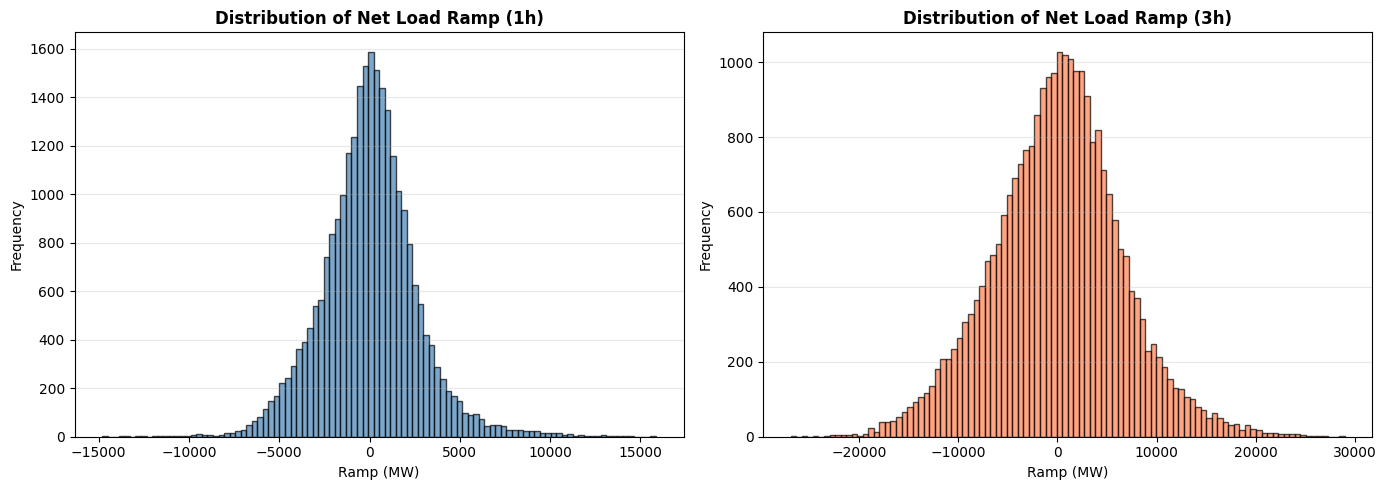

In [3]:
df["ramp_1h"] = df["NET_LOAD"].diff()
df["ramp_3h"] = df["NET_LOAD"].diff(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left subplot: 1-hour ramp
axes[0].hist(df["ramp_1h"].dropna(), bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title("Distribution of Net Load Ramp (1h)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Ramp (MW)")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis='y', alpha=0.3)

# Right subplot: 3-hour ramp
axes[1].hist(df["ramp_3h"].dropna(), bins=100, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title("Distribution of Net Load Ramp (3h)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Ramp (MW)")
axes[1].set_ylabel("Frequency")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Left: 1-hour ramp distribution (blue) — shows tighter, more concentrated distribution
## Right: 3-hour ramp distribution (coral) — shows wider spread with larger extreme values
The side-by-side layout makes it easy to compare how ramp magnitudes change over different timescales. The 3-hour ramp naturally has larger swings since it aggregates changes over a longer period.

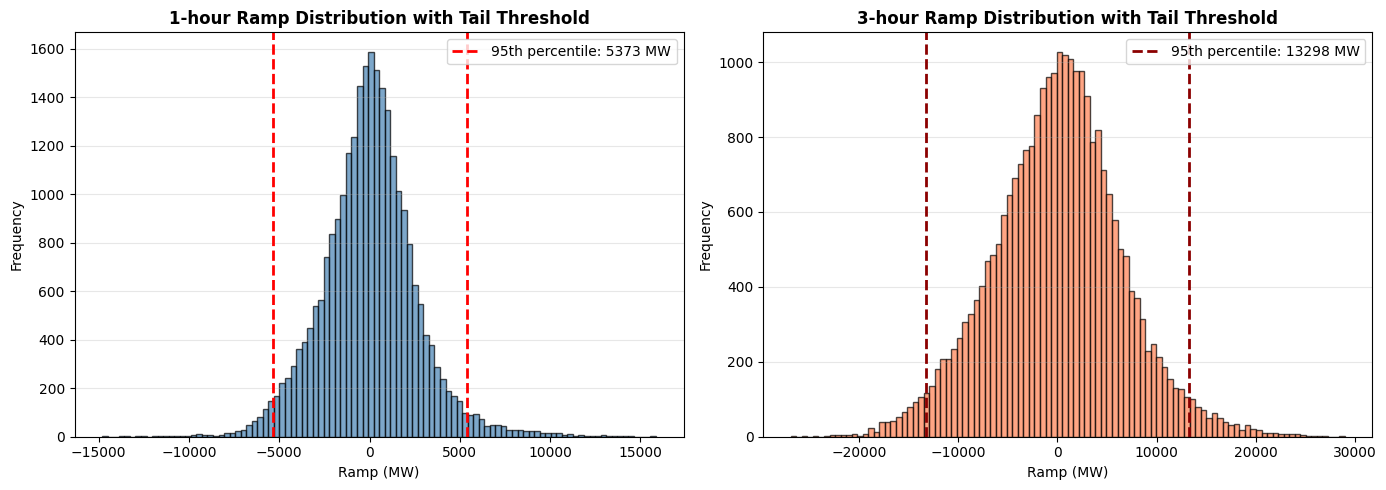

In [4]:
#Tail Region Highlight
#Purpose: visually show extreme events for both 1h and 3h ramps
threshold_1h = df["ramp_1h"].abs().quantile(0.95)
threshold_3h = df["ramp_3h"].abs().quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left subplot: 1-hour ramp with tail threshold
axes[0].hist(df["ramp_1h"].dropna(), bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(threshold_1h, color='red', linestyle="--", linewidth=2, label=f'95th percentile: {threshold_1h:.0f} MW')
axes[0].axvline(-threshold_1h, color='red', linestyle="--", linewidth=2)
axes[0].set_title("1-hour Ramp Distribution with Tail Threshold", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Ramp (MW)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Right subplot: 3-hour ramp with tail threshold
axes[1].hist(df["ramp_3h"].dropna(), bins=100, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(threshold_3h, color='darkred', linestyle="--", linewidth=2, label=f'95th percentile: {threshold_3h:.0f} MW')
axes[1].axvline(-threshold_3h, color='darkred', linestyle="--", linewidth=2)
axes[1].set_title("3-hour Ramp Distribution with Tail Threshold", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Ramp (MW)")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
# This visually defines risk region for both timescales.

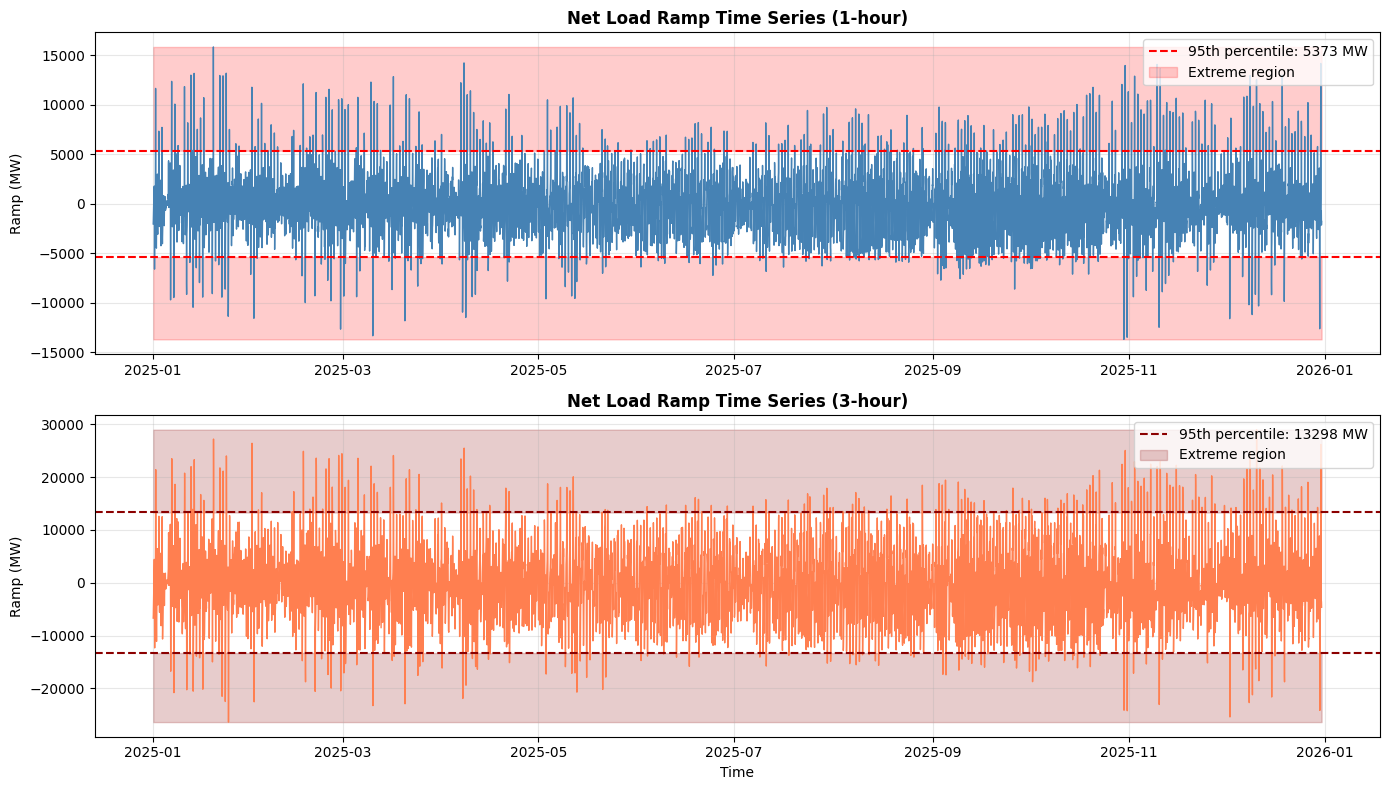

In [5]:
#Ramp Time Series (Extreme Events)
#Purpose: show when risk occurs
# Threshold defines the 95th percentile of ramp magnitudes, marking extreme events
tmp=df[df['datetime'].between('2025-01-01', '2025-12-31')]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top subplot: 1-hour ramp time series
axes[0].plot(tmp["datetime"], tmp["ramp_1h"], linewidth=1, color='steelblue')
axes[0].axhline(threshold_1h, color='red', linestyle="--", linewidth=1.5, label=f'95th percentile: {threshold_1h:.0f} MW')
axes[0].axhline(-threshold_1h, color='red', linestyle="--", linewidth=1.5)
axes[0].fill_between(tmp["datetime"], threshold_1h, tmp["ramp_1h"].max(), alpha=0.2, color='red', label='Extreme region')
axes[0].fill_between(tmp["datetime"], -threshold_1h, tmp["ramp_1h"].min(), alpha=0.2, color='red')
axes[0].set_title("Net Load Ramp Time Series (1-hour)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Ramp (MW)")
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

# Bottom subplot: 3-hour ramp time series
axes[1].plot(tmp["datetime"], tmp["ramp_3h"], linewidth=1, color='coral')
axes[1].axhline(threshold_3h, color='darkred', linestyle="--", linewidth=1.5, label=f'95th percentile: {threshold_3h:.0f} MW')
axes[1].axhline(-threshold_3h, color='darkred', linestyle="--", linewidth=1.5)
axes[1].fill_between(tmp["datetime"], threshold_3h, tmp["ramp_3h"].max(), alpha=0.2, color='darkred', label='Extreme region')
axes[1].fill_between(tmp["datetime"], -threshold_3h, tmp["ramp_3h"].min(), alpha=0.2, color='darkred')
axes[1].set_title("Net Load Ramp Time Series (3-hour)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Ramp (MW)")
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
#This shows clustering and temporal patterns of extreme ramps.

Top: 1-hour ramp with 95th percentile threshold at 5,373 MW (red dashed lines)

Bottom: 3-hour ramp with 95th percentile threshold at 13,298 MW (red dashed lines)

The shaded red regions highlight the extreme event zones above and below each threshold. This visualization makes it easy to see the temporal clustering and frequency of extreme ramps at different timescales throughout 2025.

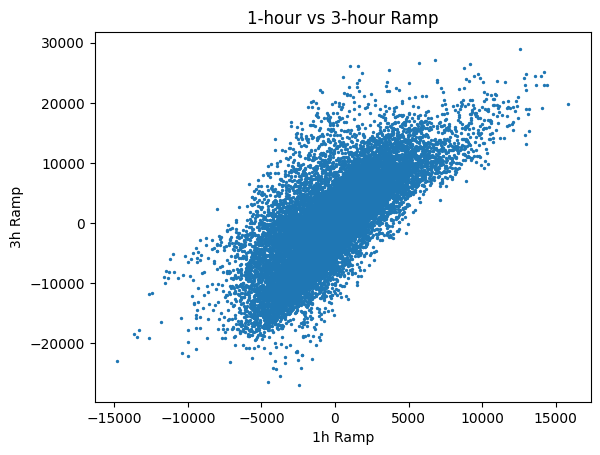

In [ ]:
#1h vs 3h Ramp Comparison
#Purpose: show sustained risk
plt.figure()
plt.scatter(df["ramp_1h"], df["ramp_3h"], s=2)
plt.title("1-hour vs 3-hour Ramp")
plt.xlabel("1h Ramp")
plt.ylabel("3h Ramp")
plt.show()
#This shows:
#sustained variability 
#operational challenge 


In [21]:
#Monthly Extreme Event Analysis
#Purpose: show seasonal patterns in risk
#However, since we only included 3 years of data, we may not have enough evidence to draw strong conclusions.
df["month"] = pd.to_datetime(df["datetime"]).dt.month

threshold = df["ramp_1h"].abs().quantile(0.95)

df["extreme"] = df["ramp_1h"].abs() > threshold

monthly_extremes = df.groupby("month")["extreme"].sum()
print(monthly_extremes)
monthly_prob = df.groupby("month")["extreme"].mean()
print(monthly_prob)

month
1     117
2      94
3      86
4      70
5      56
6      58
7     102
8     149
9     171
10    125
11    131
12    157
Name: extreme, dtype: int64
month
1     0.052419
2     0.046078
3     0.038582
4     0.032407
5     0.025090
6     0.026852
7     0.045699
8     0.066756
9     0.079167
10    0.056004
11    0.060396
12    0.070341
Name: extreme, dtype: float64


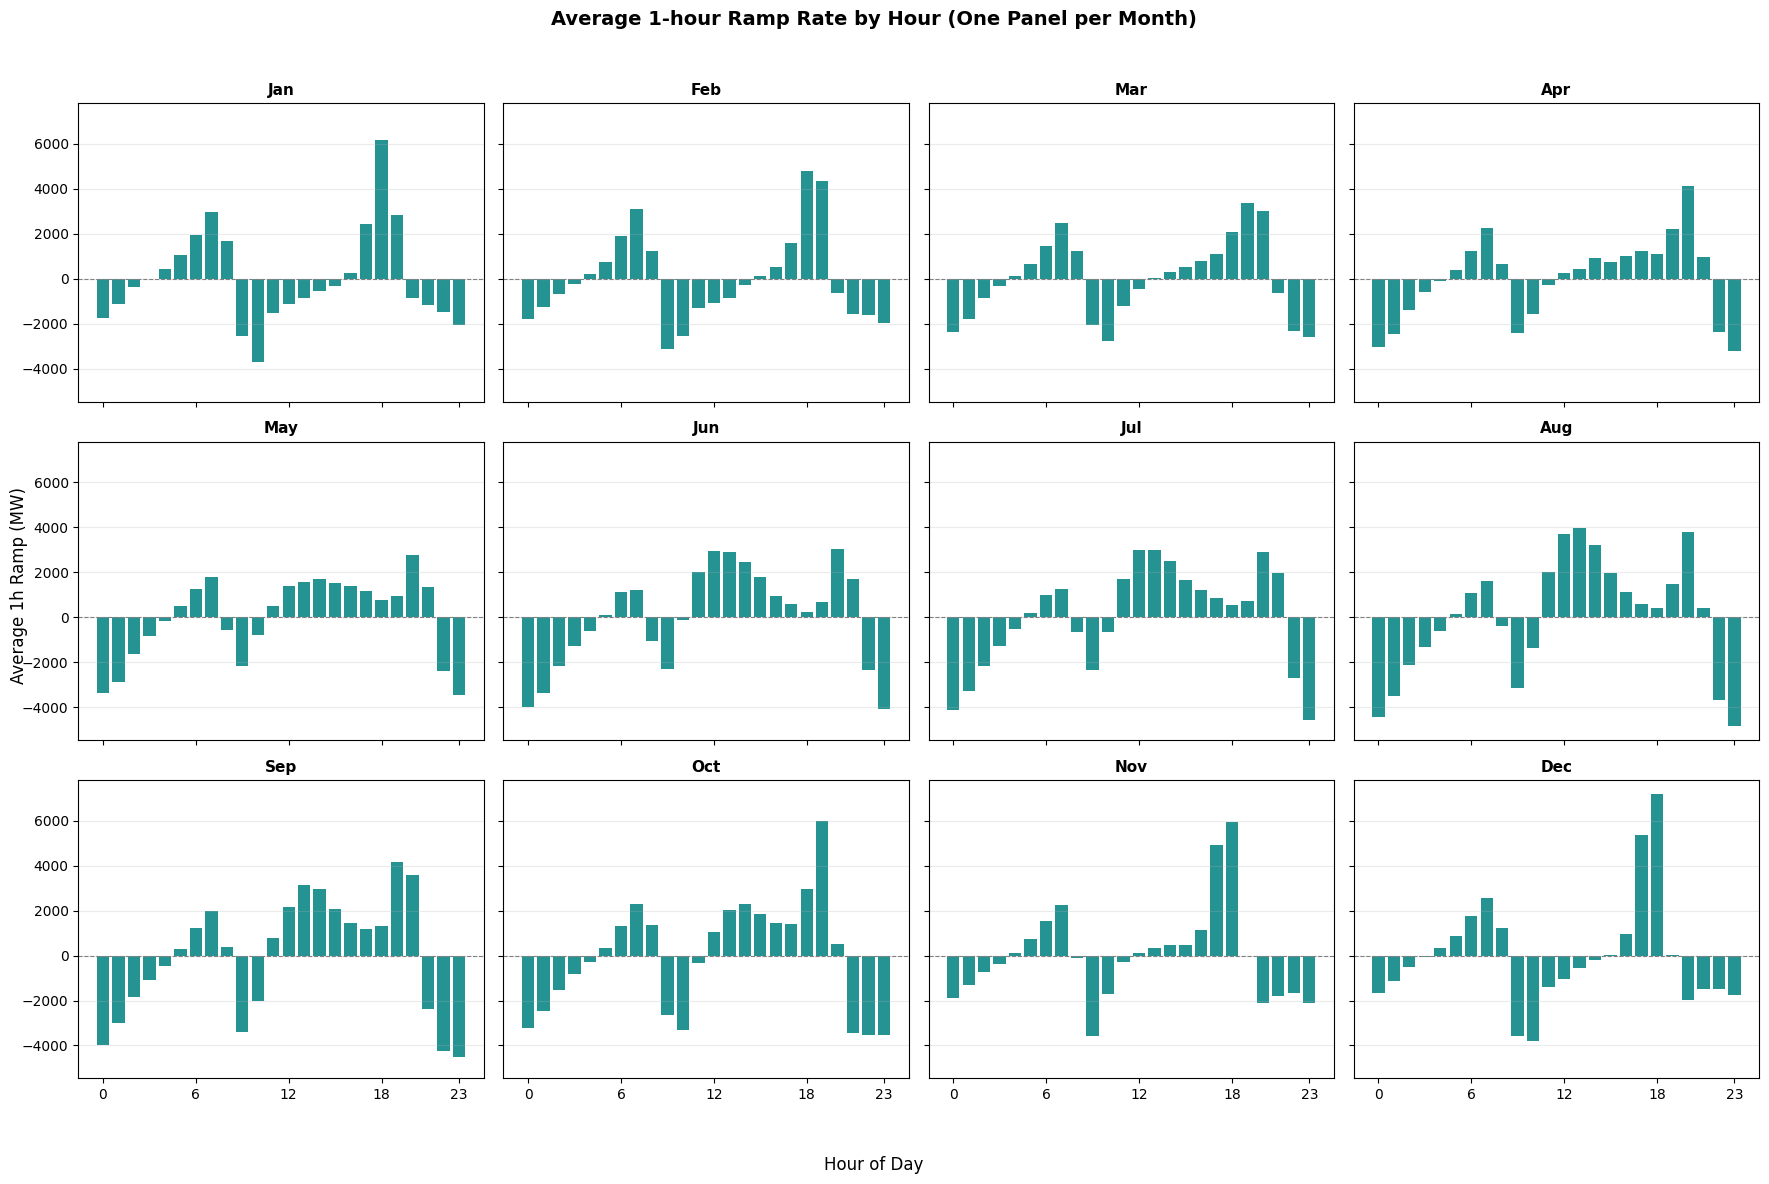

In [8]:
# 12 monthly graphs: average 1-hour ramp rate by hour of day (bar chart)
# Purpose: compare intraday ramp profile for each month (1 to 12)
df["month"] = pd.to_datetime(df["datetime"]).dt.month
df["hour"] = pd.to_datetime(df["datetime"]).dt.hour

monthly_hourly_avg_ramp = (
    df.groupby(["month", "hour"])["ramp_1h"]
    .mean()
    .unstack("hour")
    .reindex(index=range(1, 13), columns=range(24))
)

fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=True, sharey=True)
month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]

for month in range(1, 13):
    ax = axes[(month - 1) // 4, (month - 1) % 4]
    ax.bar(
        monthly_hourly_avg_ramp.columns,
        monthly_hourly_avg_ramp.loc[month].values,
        color="teal",
        alpha=0.85,
        width=0.8,
    )
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"{month_names[month - 1]}", fontsize=11, fontweight="bold")
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Average 1-hour Ramp Rate by Hour (One Panel per Month)", fontsize=14, fontweight="bold")
fig.supxlabel("Hour of Day")
fig.supylabel("Average 1h Ramp (MW)")
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

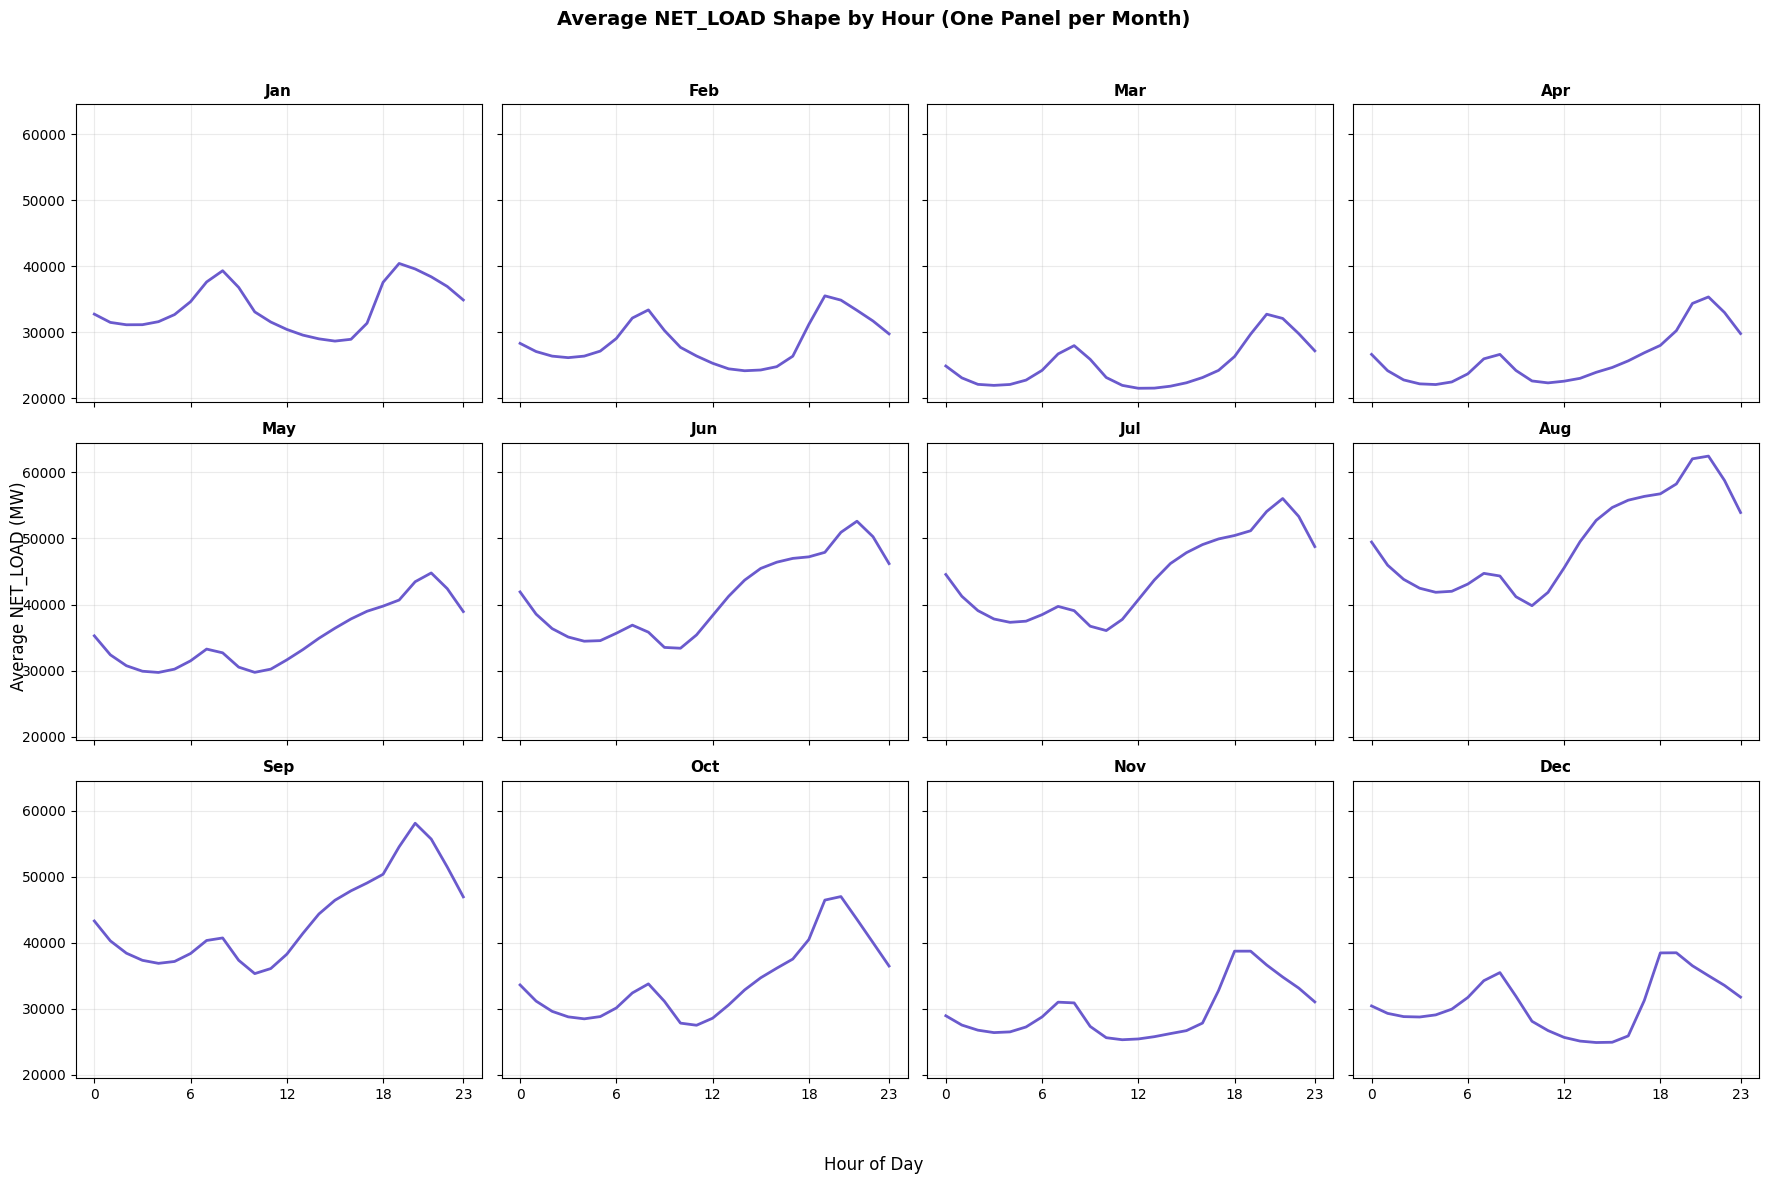

In [9]:
# 12-panel figure: average NET_LOAD shape by hour for each month
# Purpose: show monthly intraday net load profile
df["month"] = pd.to_datetime(df["datetime"]).dt.month
df["hour"] = pd.to_datetime(df["datetime"]).dt.hour

monthly_hourly_net_load = (
    df.groupby(["month", "hour"])["NET_LOAD"]
    .mean()
    .unstack("hour")
    .reindex(index=range(1, 13), columns=range(24))
)

fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=True, sharey=True)
month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]

for month in range(1, 13):
    ax = axes[(month - 1) // 4, (month - 1) % 4]
    ax.plot(
        monthly_hourly_net_load.columns,
        monthly_hourly_net_load.loc[month].values,
        color="slateblue",
        linewidth=2.0,
    )
    ax.set_title(f"{month_names[month - 1]}", fontsize=11, fontweight="bold")
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.grid(alpha=0.25)

fig.suptitle("Average NET_LOAD Shape by Hour (One Panel per Month)", fontsize=14, fontweight="bold")
fig.supxlabel("Hour of Day")
fig.supylabel("Average NET_LOAD (MW)")
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

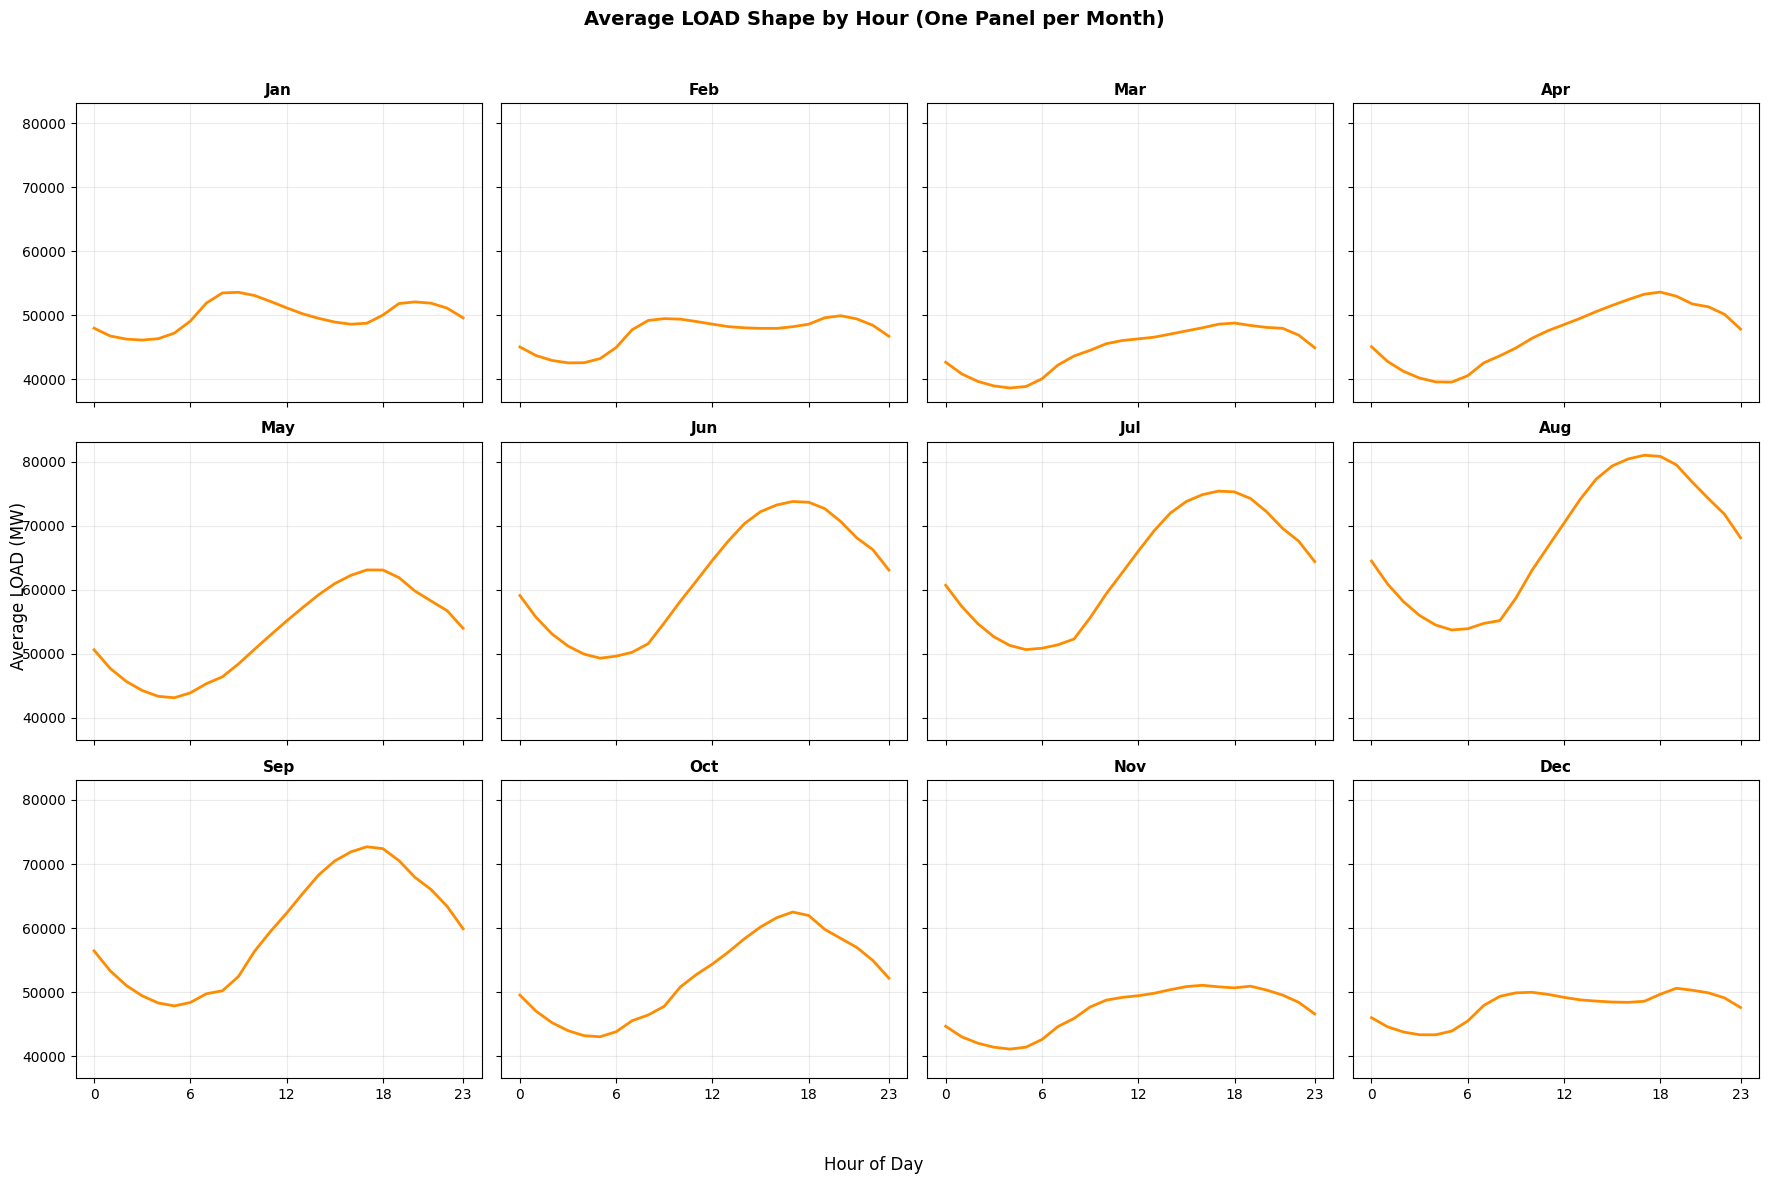

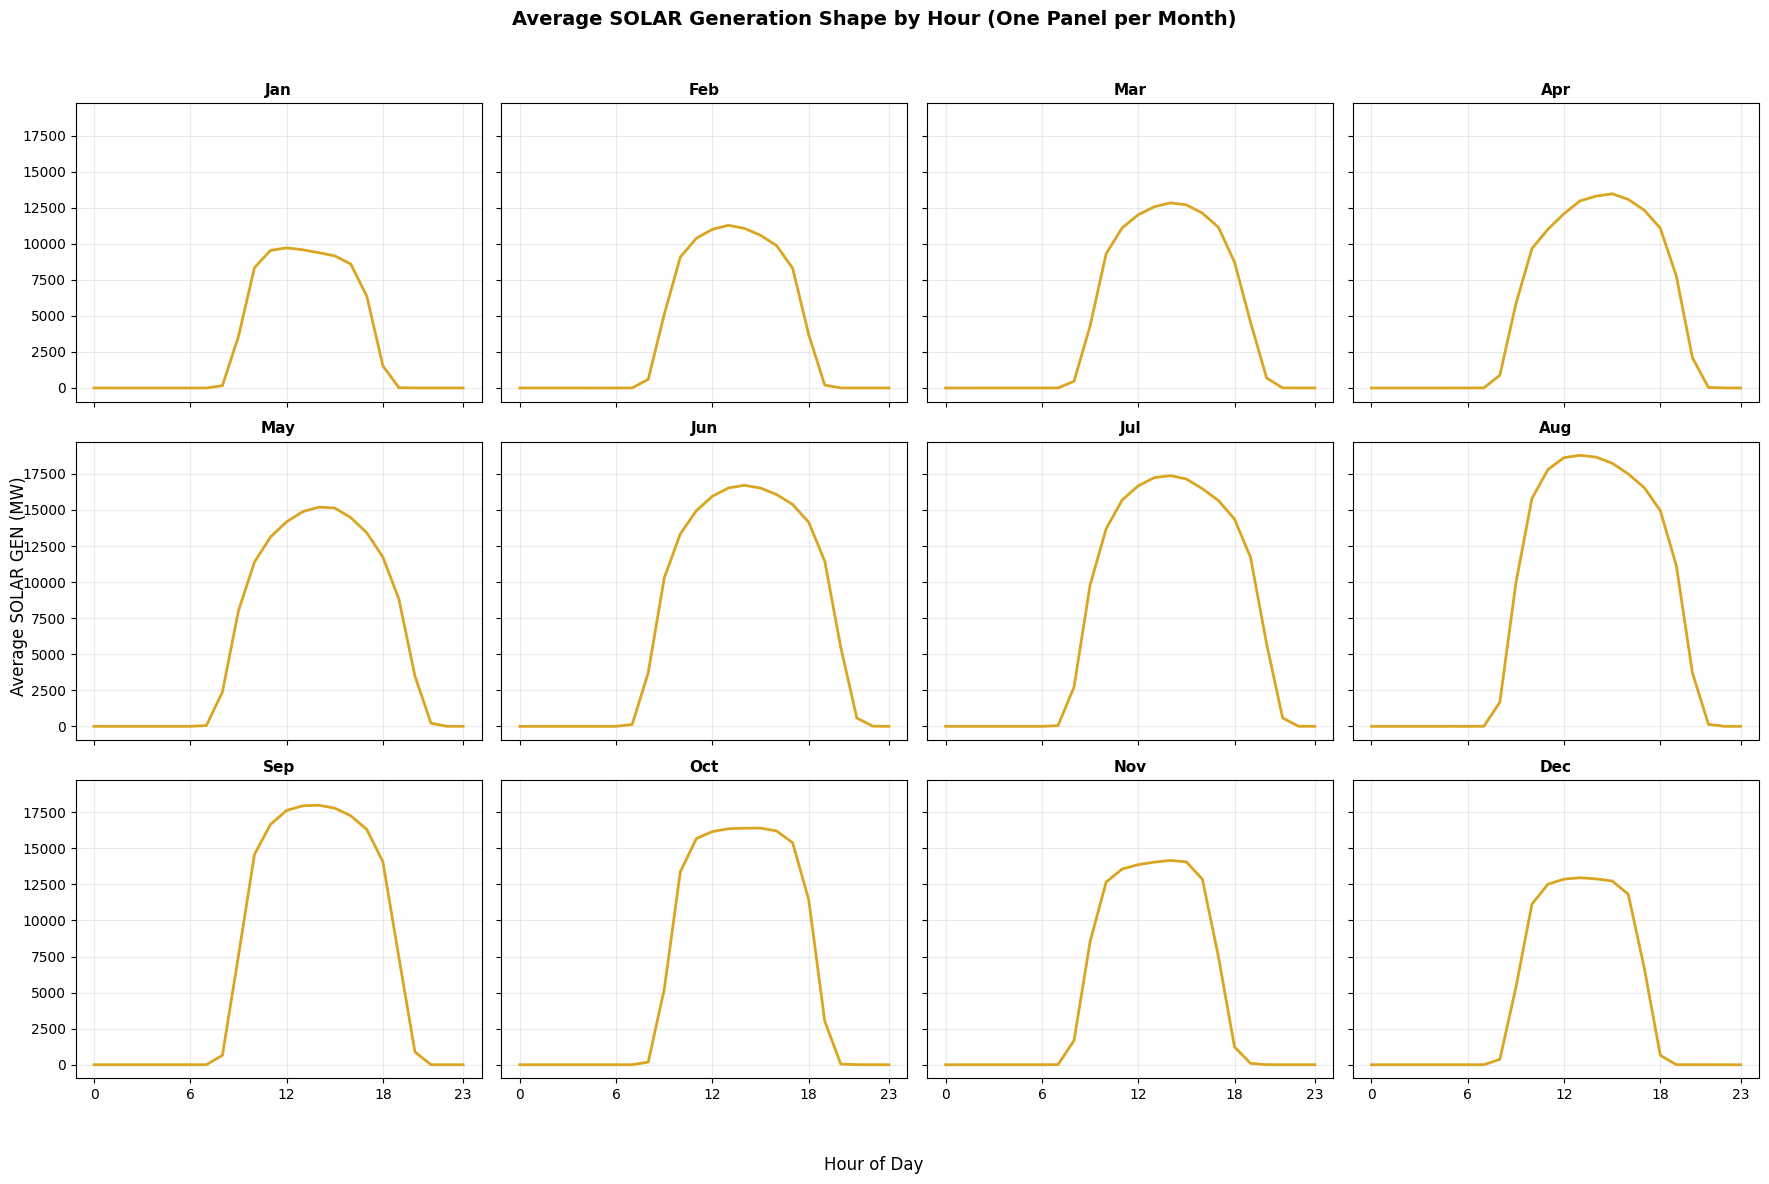

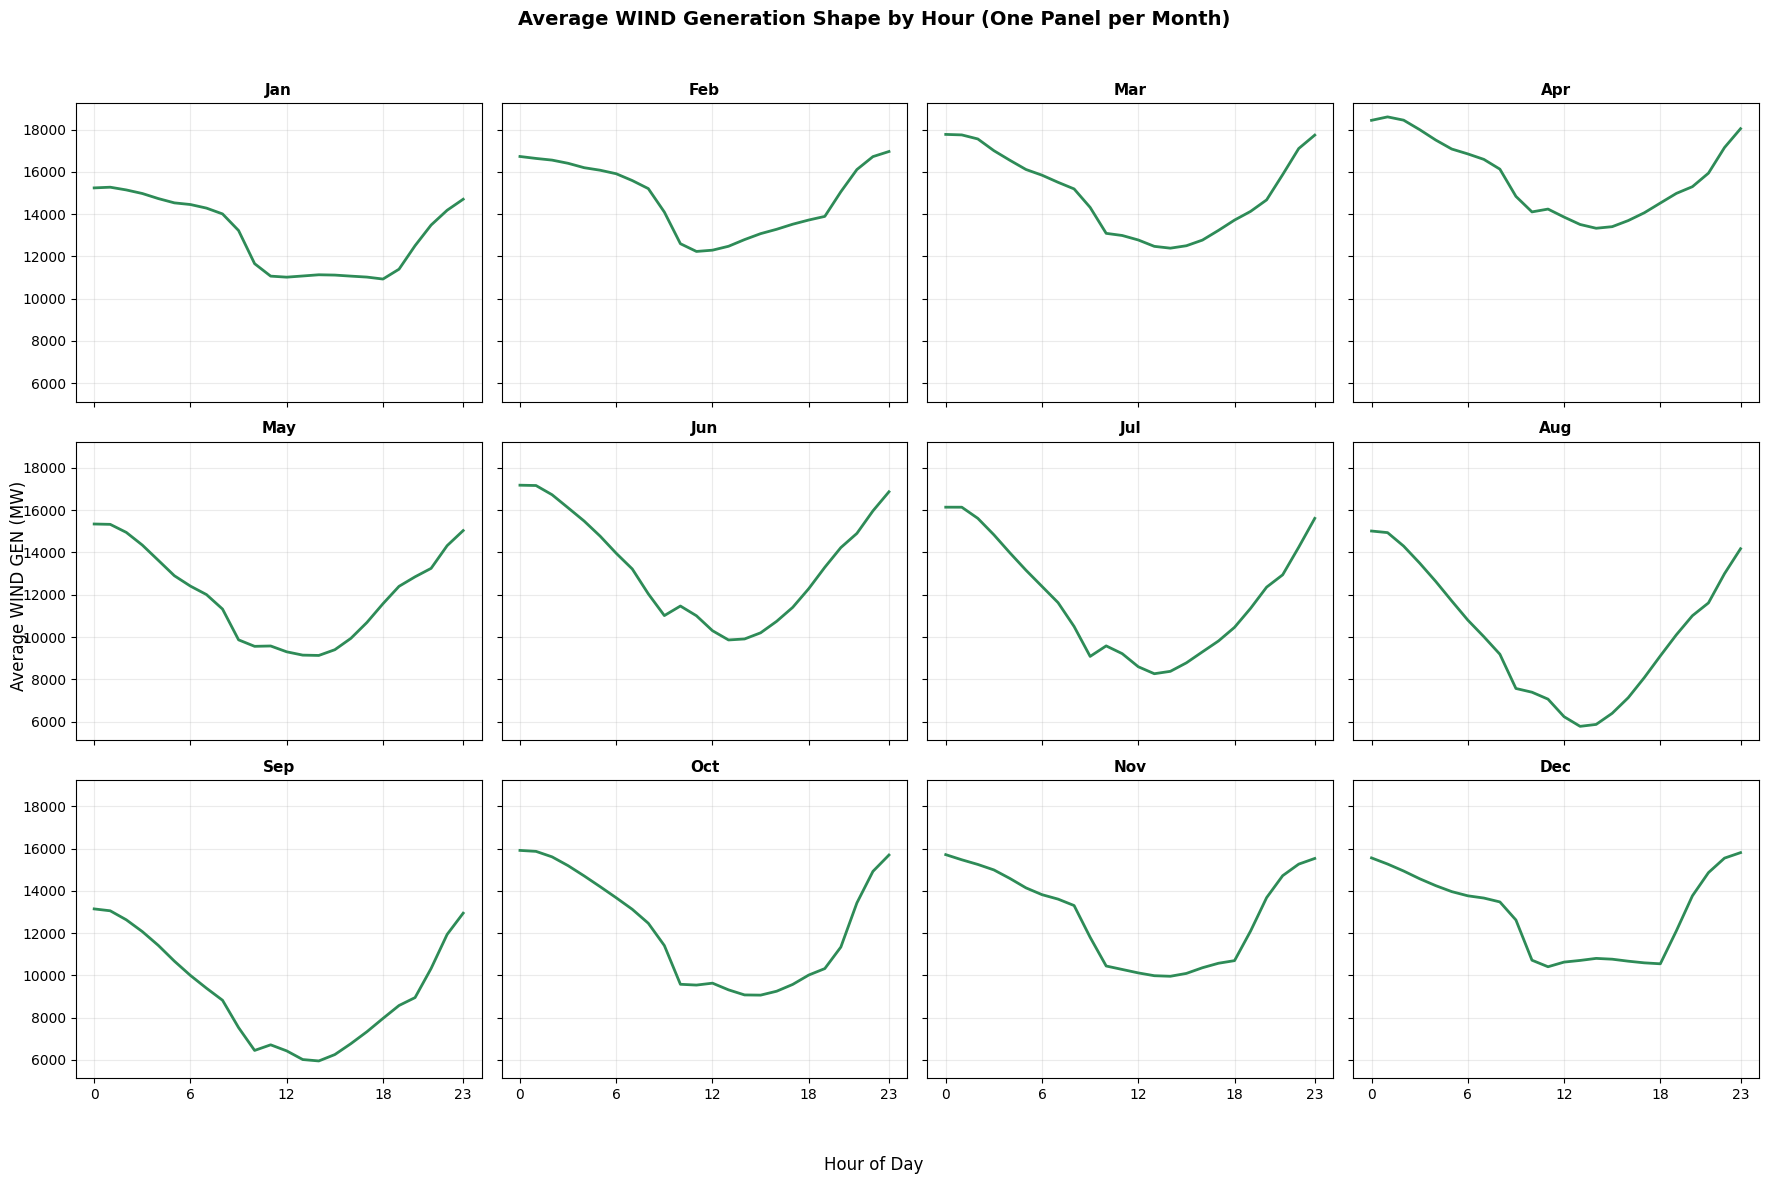

In [12]:
# Additional 12-panel shapes: LOAD, SOLAR GEN, WIND GEN
# Purpose: show monthly intraday shape for each component below NET_LOAD figure
df["month"] = pd.to_datetime(df["datetime"]).dt.month
df["hour"] = pd.to_datetime(df["datetime"]).dt.hour

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]

def plot_monthly_hourly_shape(frame, value_col, title, y_label, color):
    monthly_hourly = (
        frame.groupby(["month", "hour"])[value_col]
        .mean()
        .unstack("hour")
        .reindex(index=range(1, 13), columns=range(24))
    )

    fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=True, sharey=True)

    for month in range(1, 13):
        ax = axes[(month - 1) // 4, (month - 1) % 4]
        ax.plot(
            monthly_hourly.columns,
            monthly_hourly.loc[month].values,
            color=color,
            linewidth=2.0,
        )
        ax.set_title(f"{month_names[month - 1]}", fontsize=11, fontweight="bold")
        ax.set_xticks([0, 6, 12, 18, 23])
        ax.grid(alpha=0.25)

    fig.suptitle(title, fontsize=14, fontweight="bold")
    fig.supxlabel("Hour of Day")
    fig.supylabel(y_label)
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

plot_monthly_hourly_shape(
    df,
    value_col="ERCOT.LOAD",
    title="Average LOAD Shape by Hour (One Panel per Month)",
    y_label="Average LOAD (MW)",
    color="darkorange",
)

plot_monthly_hourly_shape(
    df,
    value_col="ERCOT.PVGR.GEN",
    title="Average SOLAR Generation Shape by Hour (One Panel per Month)",
    y_label="Average SOLAR GEN (MW)",
    color="goldenrod",
)

plot_monthly_hourly_shape(
    df,
    value_col="ERCOT.WIND.GEN",
    title="Average WIND Generation Shape by Hour (One Panel per Month)",
    y_label="Average WIND GEN (MW)",
    color="seagreen",
)

### Focus on 4-hour window around sunset (e.g., 5:00 PM to 9:00 PM).


## Three senarios will be considered in this research:

•	Base (For load, we assume the same growth rate as the most recent annual growth rate. For solar and wind, we assume that new capacity additions will match the most recent year's installed capacity.) 

•	Bear (Taking a discount to the base) 

•	Bull (Assuming faster growth than the most recent year) 

This research focuses on analyzing how renewable penetration affects grid variability, rather than forecasting load, solar, or wind. The base scenarios are constructed using the most recent annual growth rates. Bear cases are developed by applying discounts to the base scenarios, while bull cases incorporate additional growth assumptions.


In [23]:
# Load Growth Senarios
G_load_base=0.06  # Assuming 6% annual Load growth rate based on ERCOT projections
G_load_bear=0.03  #Take 3ppt away from ERCOT base case
G_load_bull=0.09  #Take 3ppt above ERCOT base case

# Solar Growth Senarios
A_solar_base=8000 # Assuming 8000 MW of new solar capacity added per year
A_solar_bear=5000 # Assuming 5000 MW of new solar capacity added per year
A_solar_bull=11000 # Assuming 11000 MW of new solar capacity added per year

# Wind Growth Senarios
# Wind no longer the primary focus in ERCOT.Texas leadership has recently prioritized dispatchable generation (gas, firm capacity) due to reliability concerns.
A_wind_base=600 # Assuming 500 MW of new wind capacity added per year
A_wind_bear=300 # Assuming 300 MW of new wind capacity added per year
A_wind_bull=900 # Assuming 700 MW of new wind capacity added per year

In [40]:
# Create separate scenario datasets extended through 2028
baseline_year = 2025
future_years = [2026, 2027, 2028]
base_mask = df["datetime"].dt.year == baseline_year
history_mask = df["datetime"].dt.year <= baseline_year

if not base_mask.any():
    raise ValueError("No 2025 baseline data found for scenario generation.")

base_profile = df.loc[base_mask].copy().sort_values("datetime").reset_index(drop=True)
solar_capacity_2025 = base_profile["ERCOT.PVGR.GEN"].max()
wind_capacity_2025 = base_profile["ERCOT.WIND.GEN"].max()

scenario_params = {
    "base": {
        "load_growth": G_load_base,
        "solar_addition": A_solar_base,
        "wind_addition": A_wind_base,
    },
    "bear": {
        # Low renewable case: bear solar & wind, bull load
        "load_growth": G_load_bull,
        "solar_addition": A_solar_bear,
        "wind_addition": A_wind_bear,
    },
    "bull": {
        # High renewable case: bull solar & wind, bear load
        "load_growth": G_load_bear,
        "solar_addition": A_solar_bull,
        "wind_addition": A_wind_bull,
    },
}

solar_shape = base_profile["ERCOT.PVGR.GEN"] / solar_capacity_2025
wind_shape = base_profile["ERCOT.WIND.GEN"] / wind_capacity_2025


def build_scenario_dataset(source_df, scenario_name, params):
    future_frames = []

    for future_year in future_years:
        years_ahead = future_year - baseline_year
        future_df = base_profile.copy()
        future_df["datetime"] = future_df["datetime"] + pd.DateOffset(years=years_ahead)

        load_multiplier = (1 + params["load_growth"]) ** years_ahead
        solar_addition_total = params["solar_addition"] * years_ahead
        wind_addition_total = params["wind_addition"] * years_ahead

        future_df["ERCOT.LOAD"] = future_df["ERCOT.LOAD"] * load_multiplier
        future_df["ERCOT.PVGR.GEN"] = (
            future_df["ERCOT.PVGR.GEN"] + solar_shape.to_numpy() * solar_addition_total
        )
        future_df["ERCOT.WIND.GEN"] = (
            future_df["ERCOT.WIND.GEN"] + wind_shape.to_numpy() * wind_addition_total
        )
        future_df["renewable"] = future_df["ERCOT.WIND.GEN"] + future_df["ERCOT.PVGR.GEN"]
        future_df["renewable_share"] = future_df["renewable"] / future_df["ERCOT.LOAD"]
        future_df["NET_LOAD"] = future_df["ERCOT.LOAD"] - future_df["renewable"]
        future_df["hour"] = future_df["datetime"].dt.hour
        future_df["month"] = future_df["datetime"].dt.month
        future_df["scenario"] = scenario_name
        future_df["forecast_year"] = future_year
        future_df["years_ahead"] = years_ahead

        future_frames.append(future_df)

    history_df = source_df.loc[history_mask].copy()
    history_df["scenario"] = "historical"
    history_df["forecast_year"] = history_df["datetime"].dt.year
    history_df["years_ahead"] = 0

    return pd.concat([history_df] + future_frames, ignore_index=True)


df_base = build_scenario_dataset(df, "base", scenario_params["base"])
df_bear = build_scenario_dataset(df, "bear", scenario_params["bear"])
df_bull = build_scenario_dataset(df, "bull", scenario_params["bull"])

print("2025 baseline capacity proxies (MW):")
print(pd.Series({
    "solar_capacity_proxy": solar_capacity_2025,
    "wind_capacity_proxy": wind_capacity_2025,
}).round(2))
print()
print("Scenario dataset shapes:")
print({
    "df_base": df_base.shape,
    "df_bear": df_bear.shape,
    "df_bull": df_bull.shape,
})
print()
print("Base scenario preview for projected years:")
display(
    df_base.loc[
        (df_base["datetime"].dt.year.isin(future_years)) & (df_base["scenario"] == "base"),
        ["datetime", "ERCOT.LOAD", "ERCOT.PVGR.GEN", "ERCOT.WIND.GEN", "NET_LOAD", "scenario", "years_ahead"],
    ].head()
)

2025 baseline capacity proxies (MW):
solar_capacity_proxy    29503.09
wind_capacity_proxy     28264.50
dtype: float64

Scenario dataset shapes:
{'df_base': (52595, 64), 'df_bear': (52595, 64), 'df_bull': (52595, 64)}

Base scenario preview for projected years:


,datetime,ERCOT.LOAD,ERCOT.PVGR.GEN,ERCOT.WIND.GEN,NET_LOAD,scenario,years_ahead
26309,2026-01-01 00:00:00,47398.383257,0.894274,13567.974319,33829.514664,base,1
26310,2026-01-01 01:00:00,46756.908472,0.921385,14674.278016,32081.709072,base,1
26311,2026-01-01 02:00:00,46423.310634,0.945010,15204.776684,31217.588939,base,1
26312,2026-01-01 03:00:00,46248.033366,0.943745,15631.650911,30615.438710,base,1
26313,2026-01-01 04:00:00,46130.483088,0.957029,15344.896189,30784.629870,base,1


In [41]:
# Save scenario datasets to CSV
base_path = PROCESSED_DIR / "hourly_load_renewable_base_scenario.csv"
bear_path = PROCESSED_DIR / "hourly_load_renewable_bear_scenario.csv"
bull_path = PROCESSED_DIR / "hourly_load_renewable_bull_scenario.csv"

df_base.to_csv(base_path, index=False)
df_bear.to_csv(bear_path, index=False)
df_bull.to_csv(bull_path, index=False)

print("Saved scenario datasets:")
print(base_path)
print(bear_path)
print(bull_path)

Saved scenario datasets:
C:\Renewable-PowerGrid-Risk\data\processed\hourly_load_renewable_base_scenario.csv
C:\Renewable-PowerGrid-Risk\data\processed\hourly_load_renewable_bear_scenario.csv
C:\Renewable-PowerGrid-Risk\data\processed\hourly_load_renewable_bull_scenario.csv


In [50]:
# Compute ramp metrics for historical 2025 and projected 2026-2028 by scenario dataset
# First, compute baseline threshold from 2025 data
baseline_2025_df = df_base[(df_base["datetime"].dt.year == 2025) & (df_base["scenario"] == "historical")].copy()
baseline_metrics = compute_risk_metrics(baseline_2025_df)
baseline_threshold = baseline_metrics["threshold_P95"]
print(f"Baseline threshold (2025): {baseline_threshold:.2f} MW")

def compute_yearly_risk_table(dataset, scenario_name, fixed_threshold):
    rows = []

    for year in [2025, 2026, 2027, 2028]:
        if year == 2025:
            year_df = dataset[(dataset["datetime"].dt.year == 2025) & (dataset["scenario"] == "historical")].copy()
        else:
            year_df = dataset[(dataset["datetime"].dt.year == year) & (dataset["scenario"] == scenario_name)].copy()

        metrics = compute_risk_metrics(year_df, fixed_threshold=fixed_threshold)
        rows.append({"scenario": scenario_name, "year": year, **metrics})

    return pd.DataFrame(rows)

risk_metrics_base = compute_yearly_risk_table(df_base, "base", baseline_threshold)
risk_metrics_bear = compute_yearly_risk_table(df_bear, "bear", baseline_threshold)
risk_metrics_bull = compute_yearly_risk_table(df_bull, "bull", baseline_threshold)
risk_metrics_all = pd.concat([risk_metrics_base, risk_metrics_bear, risk_metrics_bull], ignore_index=True)

# For 2025, keep a single baseline row
risk_metrics_all.loc[risk_metrics_all["year"] == 2025, "scenario"] = "baseline"
risk_metrics_all = risk_metrics_all.drop_duplicates(subset=["year", "scenario"]).copy()

# Sort by year first, then scenario in custom order: baseline, bear, base, bull
scenario_order = ["baseline", "bear", "base", "bull"]
risk_metrics_all["scenario"] = pd.Categorical(risk_metrics_all["scenario"], categories=scenario_order, ordered=True)
risk_metrics_all = risk_metrics_all.sort_values(["year", "scenario"]).reset_index(drop=True)

print("Projected ramp-risk metrics by scenario and year:")
display(risk_metrics_all.round(2))

Baseline threshold (2025): 6033.10 MW
Projected ramp-risk metrics by scenario and year:


,scenario,year,max_ramp_1h,threshold_P95,tail_probability,conditional_tail,p99_ramp_1h,mean_abs_ramp_1h,std_abs_ramp_1h,max_ramp_3h,p95_ramp_3h
0,baseline,2025,15862.66,6033.1,0.05,8432.59,10002.68,2172.15,2047.36,28972.66,14169.60
1,bear,2026,18318.09,6033.1,0.07,8861.29,11749.93,2475.14,2399.57,32760.81,16388.43
2,base,2026,19553.89,6033.1,0.09,9251.62,12929.59,2614.33,2639.71,34916.09,17842.37
3,bull,2026,20789.68,6033.1,0.10,9700.82,14079.44,2758.23,2897.16,37071.37,19689.46
4,bear,2027,20796.44,6033.1,0.10,9339.38,13561.19,2787.84,2766.18,36562.84,18807.99
5,base,2027,23255.30,6033.1,0.12,10243.25,15908.37,3072.80,3285.70,41004.63,22476.43
6,bull,2027,25719.25,6033.1,0.14,11251.75,18200.30,3371.19,3849.59,45712.27,26533.31
7,bear,2028,23299.77,6033.1,0.12,9837.77,15412.93,3109.56,3139.39,41080.81,21231.47
8,base,2028,26967.51,6033.1,0.15,11261.94,18938.77,3540.82,3958.20,48090.49,27132.07
9,bull,2028,31603.62,6033.1,0.18,12643.38,22406.03,3997.00,4845.48,55129.92,33590.78
